In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

In [2]:
cwd = os.getcwd()
ROOT = os.path.dirname(cwd) if os.path.basename(cwd) == "Code" else cwd
DATA_PATH = os.path.join(ROOT, "data", "volatility_dataset_013026.csv")
OUT_DIR = os.path.join(ROOT, "Code")
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join(os.getcwd(), "data", "volatility_dataset_013026.csv")
if not os.path.exists(OUT_DIR):
    OUT_DIR = cwd

In [3]:
#load data
df = pd.read_csv(DATA_PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"], format="mixed", errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date")

In [4]:
#prep features and target (SPY)
ticker = "SPY"
d = df[df["ticker"] == ticker].copy().sort_values("date")
if "daily_log_return" not in d.columns:
    d["daily_log_return"] = np.log(d["adj_close"] / d["adj_close"].shift(1))
idx = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)
d["target_vol_5d"] = d["daily_log_return"].pow(2).rolling(window=idx).sum().pow(0.5) * np.sqrt(252)
d["trailing_vol_20d"] = d["daily_log_return"].pow(2).rolling(20).sum().pow(0.5) * np.sqrt(252)
d["trailing_vol_5d"] = d["daily_log_return"].pow(2).rolling(5).sum().pow(0.5) * np.sqrt(252)
fc, tc = ["trailing_vol_20d", "trailing_vol_5d"], "target_vol_5d"
df_clean = d.dropna(subset=fc + [tc]).copy()

In [5]:
# train/val/test - train = fit params only, val = tune hyperparams & model choice (no fit), test = final eval once (no fit or tune)
tm = (df_clean["date"].dt.year >= 2015) & (df_clean["date"].dt.year <= 2021)
vm = (df_clean["date"].dt.year >= 2022) & (df_clean["date"].dt.year <= 2023)
testm = (df_clean["date"].dt.year >= 2024) & (df_clean["date"].dt.year <= 2025)
X_tr = df_clean.loc[tm, fc].values
y_tr = df_clean.loc[tm, tc].values
X_val = df_clean.loc[vm, fc].values
y_val = df_clean.loc[vm, tc].values
X_te = df_clean.loc[testm, fc].values
y_te = df_clean.loc[testm, tc].values
n = len(X_tr) + len(X_val) + len(X_te)
print(f"Train {len(X_tr)/n:.1%} (fit) | Val {len(X_val)/n:.1%} (tune only) | Test {len(X_te)/n:.1%} (eval once)")

Train 63.6% (fit) | Val 18.3% (tune only) | Test 18.2% (eval once)


In [6]:
# feature scaling: fit on train only, then transform val and test
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_te_s = scaler.transform(X_te)

In [7]:
# hyperparameter optimization for models
def build_linear(input_dim, lr=0.01):
    m = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(input_dim,), activation="linear")])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return m

def build_mlp(input_dim, units=(64, 32), dropout=0.2, lr=0.001):
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(units[0], input_shape=(input_dim,), activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(units[1], activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation="linear")
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return m

def tune_model1(X_tr, y_tr, X_val, y_val, param_grid=None, epochs=50, verbose=0):
    if param_grid is None:
        param_grid = {"lr": [1e-2, 5e-3, 1e-3], "batch_size": [16, 32]}
    best_mae, best_params, best_model = np.inf, None, None
    results = []
    for lr in param_grid["lr"]:
        for bs in param_grid["batch_size"]:
            tf.keras.backend.clear_session()
            m = build_linear(X_tr.shape[1], lr=lr)
            ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).batch(bs).prefetch(tf.data.AUTOTUNE)
            vds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(bs)
            m.fit(ds, epochs=epochs, validation_data=vds, verbose=verbose)
            _, val_mae = m.evaluate(X_val, y_val, verbose=0)
            results.append({"lr": lr, "batch_size": bs, "val_mae": val_mae})
            if val_mae < best_mae:
                best_mae, best_params, best_model = val_mae, {"lr": lr, "batch_size": bs}, m
    return best_params, best_model, pd.DataFrame(results)

def tune_model2(X_tr, y_tr, X_val, y_val, param_grid=None, epochs=50, verbose=0):
    if param_grid is None:
        param_grid = {"lr": [1e-3, 5e-4], "units": [(64, 32), (32, 16)], "dropout": [0.1, 0.2], "batch_size": [32]}
    best_mae, best_params, best_model = np.inf, None, None
    results = []
    for lr in param_grid["lr"]:
        for units in param_grid["units"]:
            for do in param_grid["dropout"]:
                for bs in param_grid["batch_size"]:
                    tf.keras.backend.clear_session()
                    m = build_mlp(X_tr.shape[1], units=units, dropout=do, lr=lr)
                    ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).batch(bs).prefetch(tf.data.AUTOTUNE)
                    vds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(bs)
                    m.fit(ds, epochs=epochs, validation_data=vds, verbose=verbose)
                    _, val_mae = m.evaluate(X_val, y_val, verbose=0)
                    results.append({"lr": lr, "units": units, "dropout": do, "batch_size": bs, "val_mae": val_mae})
                    if val_mae < best_mae:
                        best_mae, best_params, best_model = val_mae, {"lr": lr, "units": units, "dropout": do, "batch_size": bs}, m
    return best_params, best_model, pd.DataFrame(results)

In [8]:
#tune model hyperparameters
bp1, bm1, res1 = tune_model1(X_tr_s, y_tr, X_val_s, y_val, epochs=50, verbose=0)
print("Model 1 best:", bp1, "val_mae:", res1["val_mae"].min())
bp2, bm2, res2 = tune_model2(X_tr_s, y_tr, X_val_s, y_val, epochs=50, verbose=0)
print("Model 2 best:", bp2, "val_mae:", res2["val_mae"].min())

/Users/sidsridh/Desktop/school/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 best: {'lr': 0.01, 'batch_size': 32} val_mae: 0.10671280324459076
Model 2 best: {'lr': 0.0005, 'units': (32, 16), 'dropout': 0.1, 'batch_size': 32} val_mae: 0.10397990792989731


In [9]:
#bl rule - persistence (next 5d vol = current 20d vol)
y_base = X_te[:, 0]
mae_base = np.mean(np.abs(y_te - y_base))
rmse_base = np.sqrt(np.mean((y_te - y_base) ** 2))
print(f"Baseline  MAE={mae_base:.4f}  RMSE={rmse_base:.4f}")

Baseline  MAE=0.3570  RMSE=0.4796


In [10]:
#model 1: linear regression with tf
m1 = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(len(fc),), activation="linear")])
m1.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="mse", metrics=["mae", "mse"])
bs = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_tr_s, y_tr)).batch(bs).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_s, y_val)).batch(bs).prefetch(tf.data.AUTOTUNE)
m1.fit(train_ds, epochs=50, validation_data=val_ds, verbose=1)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0476 - mae: 1.0187 - mse: 3.0476 - val_loss: 1.7259 - val_mae: 0.9964 - val_mse: 1.7259
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - loss: 2.1134 - mae: 0.8132 - mse: 2.1134 - val_loss: 1.2051 - val_mae: 0.8285 - val_mse: 1.2051
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 1.5547 - mae: 0.7083 - mse: 1.5547 - val_loss: 0.8372 - val_mae: 0.6876 - val_mse: 0.8372
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 1.1279 - mae: 0.6114 - mse: 1.1279 - val_loss: 0.5776 - val_mae: 0.5682 - val_mse: 0.5776
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.8065 - mae: 0.5228 - mse: 0.8065 - val_loss: 0.3959 - val_mae: 0.4687 - val_mse: 0.3959
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.5693 - mae: 0.4428 - mse: 0.5693 - val_loss: 0.2702 - val_mae: 0.3860 - val_mse: 0.2702
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 0.3985 - mae: 0.3724 - mse: 0.3985 - val_l

Model 1 MAE = 0.103155717253685 RMSE = 0.17600707806739577


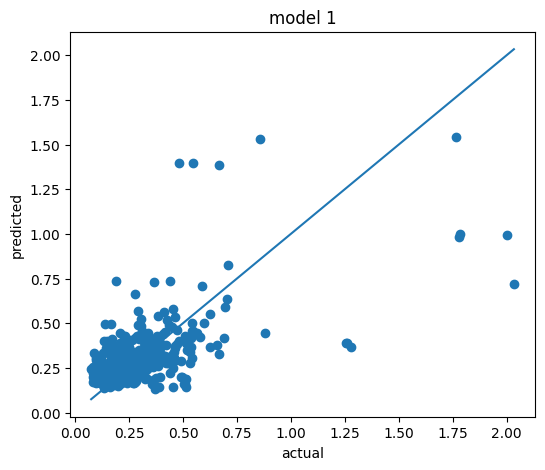

In [11]:
#model 1: eval and plot
_, mae1, mse1 = m1.evaluate(X_te_s, y_te, verbose=0)
y1 = m1.predict(X_te_s, verbose=0).flatten()
print("Model 1 MAE =", mae1, "RMSE =", np.sqrt(mse1))
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(y_te, y1)
l = [min(y_te.min(), y1.min()), max(y_te.max(), y1.max())]
ax.plot(l, l)
ax.set_xlabel("actual")
ax.set_ylabel("predicted")
ax.set_title("model 1")
# plt.savefig(os.path.join(OUT_DIR, "model1_scatter.png"))
plt.show()

In [12]:
#model 2
m2 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_shape=(len(fc),), activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="linear")
])
m2.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse", metrics=["mae", "mse"])
m2.fit(train_ds, epochs=80, validation_data=val_ds, verbose=1)

Epoch 1/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0789 - mae: 0.1852 - mse: 0.0789 - val_loss: 0.0437 - val_mae: 0.1646 - val_mse: 0.0437
Epoch 2/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - loss: 0.0484 - mae: 0.1369 - mse: 0.0484 - val_loss: 0.0226 - val_mae: 0.1101 - val_mse: 0.0226
Epoch 3/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - loss: 0.0423 - mae: 0.1250 - mse: 0.0423 - val_loss: 0.0239 - val_mae: 0.1128 - val_mse: 0.0239
Epoch 4/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - loss: 0.0408 - mae: 0.1213 - mse: 0.0408 - val_loss: 0.0213 - val_mae: 0.1054 - val_mse: 0.0213
Epoch 5/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 0.0361 - mae: 0.1185 - mse: 0.0361 - val_loss: 0.0209 - val_mae: 0.1046 - val_mse: 0.0209
Epoch 6/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 0.0330 - mae: 0.1130 - mse: 0.0330 - val_loss: 0.0205 - val_mae: 0.1035 - val_mse: 0.0205
Epoch 7/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.0328 - mae: 0.1120 - mse: 0.0328 - val_l

Model 2   MAE=0.1000  RMSE=0.1719


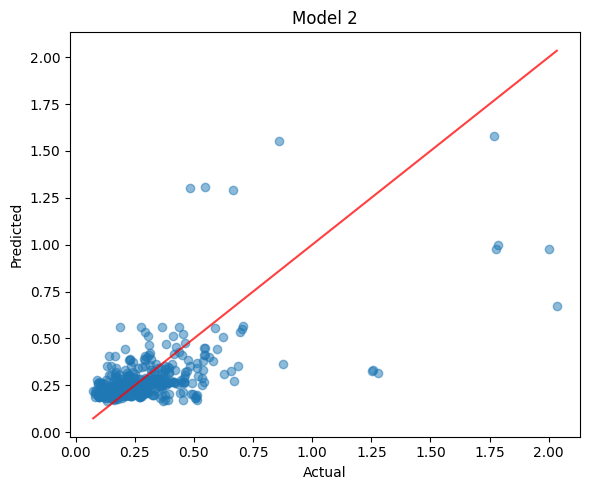

In [13]:
#model 2: eval and plot
_, mae2, mse2 = m2.evaluate(X_te_s, y_te, verbose=0)
y2 = m2.predict(X_te_s, verbose=0).flatten()
print(f"Model 2   MAE={mae2:.4f}  RMSE={np.sqrt(mse2):.4f}")
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(y_te, y2, alpha=0.5)
l = [min(y_te.min(), y2.min()), max(y_te.max(), y2.max())]
ax.plot(l, l, "r-", alpha=0.75)
ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.set_title("Model 2")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "model2_scatter.png")); plt.show()

In [15]:
#summary, save
sum_df = pd.DataFrame({"Model": ["Baseline", "Model 1", "Model 2"], "MAE": [mae_base, mae1, mae2], "RMSE": [rmse_base, np.sqrt(mse1), np.sqrt(mse2)]})
m1.save(os.path.join(OUT_DIR, "model1_linear.keras"))
m2.save(os.path.join(OUT_DIR, "model2_mlp.keras"))
print(sum_df)

      Model       MAE      RMSE
0  Baseline  0.357030  0.479584
1   Model 1  0.103156  0.176007
2   Model 2  0.100018  0.171920
